# Демо · Языковая модель вживую

Маленькая языковая модель, `Qwen/Qwen3-0.6B-Base`, base-версия без чат-дообучения, чистое «продолжи текст». Код device-agnostic: CUDA, Apple MPS, CPU. Модель скачивается с Hugging Face при первом запуске, картинки сохраняются в `fallback/`.

Что показываем:
1. Модель на каждом шаге выдает **распределение** над следующим токеном, а не ответ. Однозначный контекст собирает вероятность в одном токене, неоднозначный размазывает.
2. **Температура** не добавляет знаний, она меняет остроту того же распределения. Сначала картинка, потом пять продолжений одного промпта.
3. **Правдоподобие текста**, сумма логарифмов вероятностей токенов: связный текст правдоподобнее перемешанного. Это то число, которое максимизировалось при обучении.

Та же биграммная модель из счетчиков, что на лекции, только предшественников не одно слово, а весь контекст, и таблицу заменила сеть.


In [8]:
import os, math, torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM

plt.rcParams.update({"figure.dpi": 110, "font.size": 12})
os.makedirs("fallback", exist_ok=True)

MODEL_ID = os.environ.get("TGO_MODEL_ID", "Qwen/Qwen3-0.6B-Base")

device = "cuda" if torch.cuda.is_available() else (
    "mps" if torch.backends.mps.is_available() else "cpu"
)
print("device:", device)

tok = AutoTokenizer.from_pretrained(MODEL_ID)
try:
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, dtype=torch.float32
    )
except TypeError:
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, torch_dtype=torch.float32
    )  # transformers 4.x
model = model.to(device).eval()
print(f"модель: {MODEL_ID}, параметров: {sum(p.numel() for p in model.parameters())/1e6:.0f} млн, словарь: {len(tok)} токенов")

device: mps


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

модель: Qwen/Qwen3-0.6B-Base, параметров: 596 млн, словарь: 151669 токенов


## 1. Распределение следующего токена

Один прямой проход: на выходе — по числу на каждый токен словаря (это и есть *логиты*), softmax превращает их в вероятности.

In [9]:
@torch.no_grad()
def next_token_logits(prompt: str) -> torch.Tensor:
    ids = tok(prompt, return_tensors="pt").to(device)
    out = model(**ids)
    return out.logits[0, -1].float().cpu()          # логиты последней позиции: [vocab]

def top_k_table(logits: torch.Tensor, k: int = 10, temperature: float = 1.0):
    probs = torch.softmax(logits / temperature, dim=-1)
    p, idx = probs.topk(k)
    tokens = [tok.decode([i]).replace("\n", "⏎") for i in idx.tolist()]
    return tokens, p.numpy()

def show_distribution(prompt: str, k: int = 10, ax=None, temperature: float = 1.0, title=None):
    logits = next_token_logits(prompt)
    tokens, p = top_k_table(logits, k, temperature)
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4))
    ax.barh(range(k)[::-1], p, color="tab:blue")
    ax.set_yticks(range(k)[::-1]); ax.set_yticklabels([repr(t) for t in tokens])
    ax.set_xlim(0, 1); ax.set_xlabel("P(следующий токен)")
    ax.set_title(title or f"«{prompt}» …")
    for y, v in zip(range(k)[::-1], p):
        ax.text(min(v + 0.01, 0.9), y, f"{v:.2f}", va="center")
    return logits


### Пробник: какой контекст действительно однозначный

Токенизатор режет русские слова на куски, поэтому после «Столица России — город» следующим токеном может быть начало десятков слов, и верхняя вероятность выходит около 0.1. Нужен контекст, где следующий токен один и целый. Ниже кандидаты с вероятностью top-1: для слайда берется тот, где она ближе к единице.

In [10]:
candidates = ["import numpy as", "The capital of France is", "2, 4, 6, 8,", "Дважды два равно", "Столица России — город", "Сегодня я хочу"]
for pr in candidates:
    tokens, p = top_k_table(next_token_logits(pr), 3)
    print(f"{pr!r:32} top-1 = {tokens[0]!r:12} {p[0]:.2f}   далее: {tokens[1]!r} {p[1]:.2f}, {tokens[2]!r} {p[2]:.2f}")

'import numpy as'                top-1 = ' np'        1.00   далее: ' _' 0.00, ' numpy' 0.00
'The capital of France is'       top-1 = ' Paris'     0.35   далее: ' ____' 0.11, ' __' 0.07
'2, 4, 6, 8,'                    top-1 = ' '          0.82   далее: ' and' 0.05, ' ...' 0.03
'Дважды два равно'               top-1 = ' дв'        0.38   далее: ' как' 0.10, ' два' 0.08
'Столица России — город'         top-1 = ' Москва'    0.10   далее: ' С' 0.05, ',' 0.05
'Сегодня я хочу'                 top-1 = ' расс'      0.16   далее: ' п' 0.06, ' под' 0.04


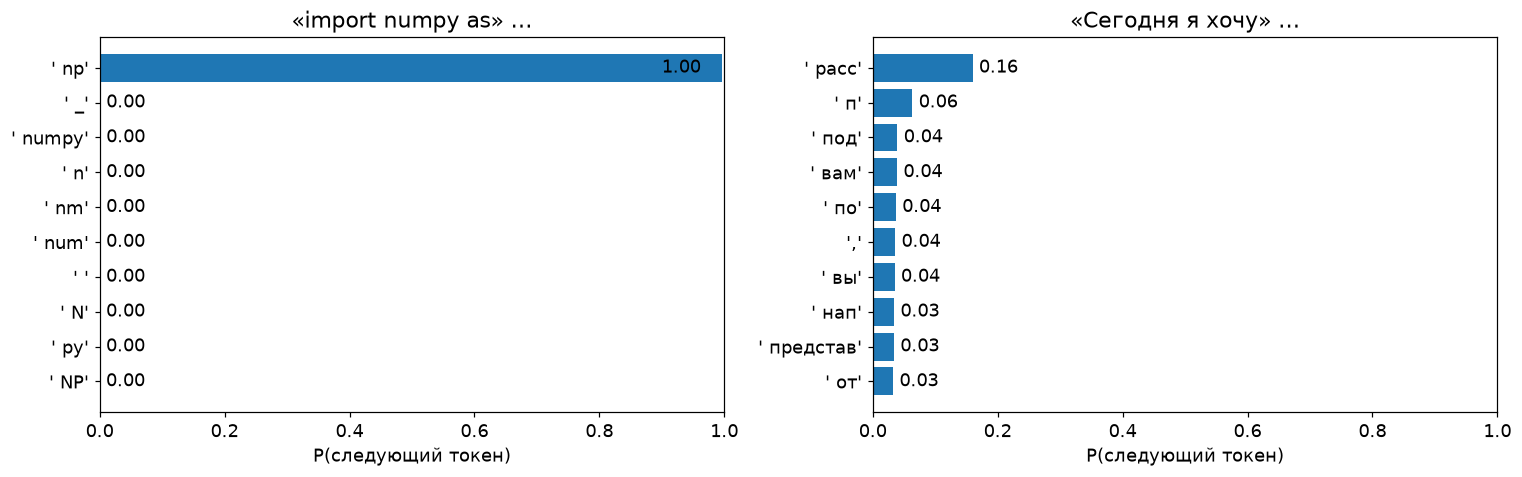

In [11]:
prompts = ["import numpy as", "Сегодня я хочу"]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, pr in zip(axes, prompts):
    show_distribution(pr, ax=ax)
plt.tight_layout(); plt.savefig("fallback/01_distributions.png", bbox_inches="tight"); plt.show()

## 2. Температура: те же логиты, другая форма

Температура делит логиты перед softmax. Знаний у модели не прибавляется, меняется только острота распределения.


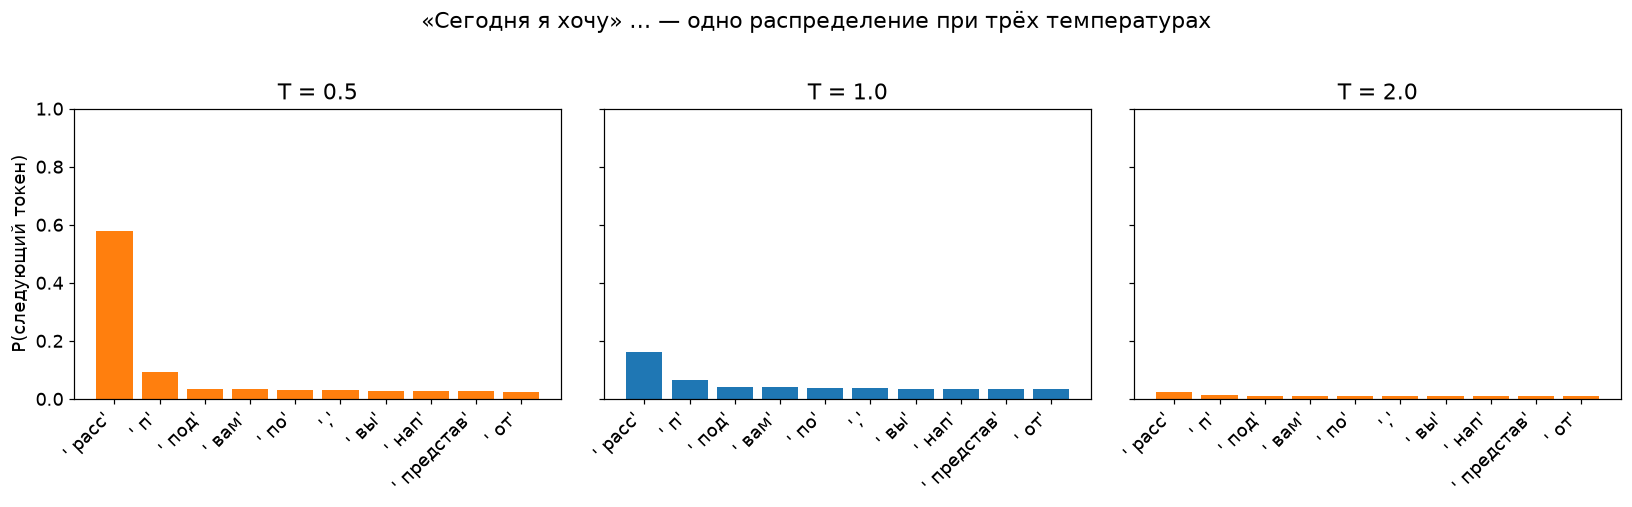

In [12]:
prompt = "Сегодня я хочу"
logits = next_token_logits(prompt)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, T in zip(axes, [0.5, 1.0, 2.0]):
    tokens, p = top_k_table(logits, 10, T)
    ax.bar(range(10), p, color="tab:orange" if T != 1.0 else "tab:blue")
    ax.set_xticks(range(10)); ax.set_xticklabels([repr(t) for t in tokens], rotation=45, ha="right")
    ax.set_title(f"T = {T}"); ax.set_ylim(0, 1)
axes[0].set_ylabel("P(следующий токен)")
fig.suptitle(f"«{prompt}» … — одно распределение при трёх температурах", y=1.02)
plt.tight_layout(); plt.savefig("fallback/02_temperature.png", bbox_inches="tight"); plt.show()

### Генерация это сэмплирование

Текст получается так: на каждом шаге из распределения над следующим токеном случайно вытягивается один, по вероятностям, и шаг повторяется. Поэтому на один и тот же промпт модель дает разные продолжения. Ниже пять продолжений при низкой и при высокой температуре: при низкой они почти одинаковые, при высокой разнообразные и местами странные. `do_sample=False` вместо этого берет самый вероятный токен, и продолжения становятся одинаковыми.


In [13]:
@torch.no_grad()
def sample(prompt: str, temperature: float, n: int = 5, max_new_tokens: int = 12, seed: int = 0):
    torch.manual_seed(seed)
    ids = tok(prompt, return_tensors="pt").to(device)
    out = model.generate(**ids, do_sample=True, temperature=temperature, top_k=0, top_p=1.0,
                         max_new_tokens=max_new_tokens, num_return_sequences=n,
                         pad_token_id=tok.eos_token_id)
    return [tok.decode(o[ids["input_ids"].shape[1]:], skip_special_tokens=True) for o in out]

for T in [0.3, 1.2]:
    print(f"\n=== T = {T} ===")
    for s in sample("Сегодня я хочу", T):
        print("  …" + s.replace("\n", " ⏎ "))


=== T = 0.3 ===
  … рассказать о том, как можно сделать свой дом более у
  … рассказать вам о том, как можно использовать визу
  … рассказать о том, что такое «самооцен
  … рассказать о том, как я справляюсь с проблем
  … рассказать о том, как я сталкивалась

=== T = 1.2 ===
  …, чтобы каждый **похоже был на какой либо
  … показать вам, что раз и прожил практически всегда уровень
  … анонимно идейно «подглядывать_PAUSE
  … наставник." ⏎  ⏎ Human: я высоко оценил
  … обсудить два очень интересные йуг уст


## 3. Правдоподобие текста

Сумма логарифмов вероятностей каждого токена при известном начале:

$$\log P(x_1 \dots x_T) = \sum_{t=1}^{T} \log P(x_t \mid x_{<t})$$

То же, что с монеткой: вероятности, логарифм, сумма. Обучение подбирает параметры, при которых реальные тексты дают эту сумму как можно больше. Проверим: связное предложение против тех же слов в случайном порядке.


In [14]:
@torch.no_grad()
def sequence_log_likelihood(text: str):
    ids = tok(text, return_tensors="pt").to(device)["input_ids"]
    logits = model(ids).logits[0, :-1].float() # предсказания для позиций 1..T
    logp = torch.log_softmax(logits, dim=-1)
    target = ids[0, 1:]
    token_logp = logp[torch.arange(target.numel()), target].cpu()
    return token_logp.sum().item(), token_logp.numel()

texts = {
    "связный текст": "Москва — столица России и крупнейший город страны.",
    "те же слова вперемешку": "Страны город и — крупнейший Москва столица России.",
}
for name, t in texts.items():
    ll, n = sequence_log_likelihood(t)
    print(f"{name:<26} log P = {ll:8.1f}   (на токен: {ll/n:6.2f},  perplexity: {math.exp(-ll/n):8.1f})")

связный текст              log P =    -21.9   (на токен:  -1.57,  perplexity:      4.8)
те же слова вперемешку     log P =    -64.0   (на токен:  -4.57,  perplexity:     96.8)
